In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import swin_t, Swin_T_Weights
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import accuracy_score, f1_score
from collections import defaultdict

# ========================
# FIX RANDOMNESS (STABLE RESULTS)
# ========================

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

# ========================
# SETTINGS (FASTER)
# ========================

DATASET_PATH = "dataset"
SHOTS = [5, 10, 20, 30]
EPOCHS = 18
VAL_PER_CLASS = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

# ========================
# TRANSFORM (CONTROLLED)
# ========================

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

dataset = ImageFolder(DATASET_PATH, transform=transform)
num_classes = len(dataset.classes)

print("Classes:", dataset.classes)

# ========================
# FIXED CLASS ORDER
# ========================

class_indices = defaultdict(list)

for idx, (_, label) in enumerate(dataset.samples):
    class_indices[label].append(idx)

for label in class_indices:
    random.shuffle(class_indices[label])

# ========================
# FEW SHOT FUNCTION
# ========================

def run_few_shot(K_SHOT):

    print("\n=================================")
    print(f"        RUNNING {K_SHOT}-SHOT")
    print("=================================")

    train_indices = []
    val_indices = []

    for label in class_indices:
        train_part = class_indices[label][:K_SHOT]
        val_part = class_indices[label][K_SHOT:K_SHOT+VAL_PER_CLASS]

        train_indices.extend(train_part)
        val_indices.extend(val_part)

        print(f"{dataset.classes[label]} → "
              f"{len(train_part)} train | {len(val_part)} val")

    train_dataset = Subset(dataset, train_indices)
    val_dataset = Subset(dataset, val_indices)

    # ✅ Faster loaders
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

    # ========================
    # MODEL
    # ========================

    model = swin_t(weights=Swin_T_Weights.DEFAULT)
    model.head = nn.Linear(model.head.in_features, num_classes)

    for param in model.parameters():
        param.requires_grad = False

    for param in model.features[-3:].parameters():
        param.requires_grad = True

    for param in model.norm.parameters():
        param.requires_grad = True

    for param in model.head.parameters():
        param.requires_grad = True

    model = model.to(device)

    # ✅ Slight regularization
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    # ✅ Controlled LR (boost only for 30-shot)
    lr = 1.5e-4 if K_SHOT < 30 else 2e-4

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS
    )

    best_acc = 0

    # ========================
    # TRAIN LOOP
    # ========================

    for epoch in range(EPOCHS):

        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            # ✅ Boost stability for 30-shot
            if K_SHOT >= 30:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            running_loss += loss.item()

        scheduler.step()

        # ========================
        # VALIDATION
        # ========================

        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                preds = torch.argmax(outputs, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        acc = accuracy_score(all_labels, all_preds) * 100
        f1 = f1_score(all_labels, all_preds, average="macro") * 100

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(),
                       f"swin_{K_SHOT}shot_best.pth")

        print(f"[{K_SHOT}-Shot | Epoch {epoch+1}/{EPOCHS}] "
              f"Loss: {running_loss:.4f} | "
              f"Acc: {acc:.2f}% | "
              f"F1: {f1:.2f}% | "
              f"Best: {best_acc:.2f}%")

    print(f"\nFinal Best Accuracy for {K_SHOT}-Shot: {best_acc:.2f}%")
    return best_acc


# ========================
# RUN ALL SHOTS
# ========================

results = {}

for shot in SHOTS:
    acc = run_few_shot(shot)
    results[shot] = acc

print("\n================ FINAL RESULTS ================")
for k, v in results.items():
    print(f"{k}-Shot → {v:.2f}%")


Using Device: cuda
Classes: ['DominantFollicle', 'Normal', 'PCO']

        RUNNING 5-SHOT
DominantFollicle → 5 train | 100 val
Normal → 5 train | 36 val
PCO → 5 train | 100 val
[5-Shot | Epoch 1/18] Loss: 1.9614 | Acc: 58.90% | F1: 60.16% | Best: 58.90%
[5-Shot | Epoch 2/18] Loss: 1.1440 | Acc: 59.32% | F1: 59.85% | Best: 59.32%
[5-Shot | Epoch 3/18] Loss: 1.0911 | Acc: 69.92% | F1: 73.25% | Best: 69.92%
[5-Shot | Epoch 4/18] Loss: 0.7552 | Acc: 59.32% | F1: 57.88% | Best: 69.92%
[5-Shot | Epoch 5/18] Loss: 0.9226 | Acc: 52.54% | F1: 46.02% | Best: 69.92%
[5-Shot | Epoch 6/18] Loss: 0.5546 | Acc: 64.83% | F1: 63.61% | Best: 69.92%
[5-Shot | Epoch 7/18] Loss: 0.5747 | Acc: 56.36% | F1: 52.45% | Best: 69.92%
[5-Shot | Epoch 8/18] Loss: 0.9191 | Acc: 67.37% | F1: 65.78% | Best: 69.92%
[5-Shot | Epoch 9/18] Loss: 0.5628 | Acc: 63.98% | F1: 62.61% | Best: 69.92%
[5-Shot | Epoch 10/18] Loss: 0.4218 | Acc: 60.59% | F1: 58.42% | Best: 69.92%
[5-Shot | Epoch 11/18] Loss: 0.4084 | Acc: 58.90% | 

Using Device: cuda
Selected Image: dataset/DominantFollicle/Dominant_Follicle_84.jpg
True Class: DominantFollicle
Hooking Layer: norm
Predicted Class: DominantFollicle


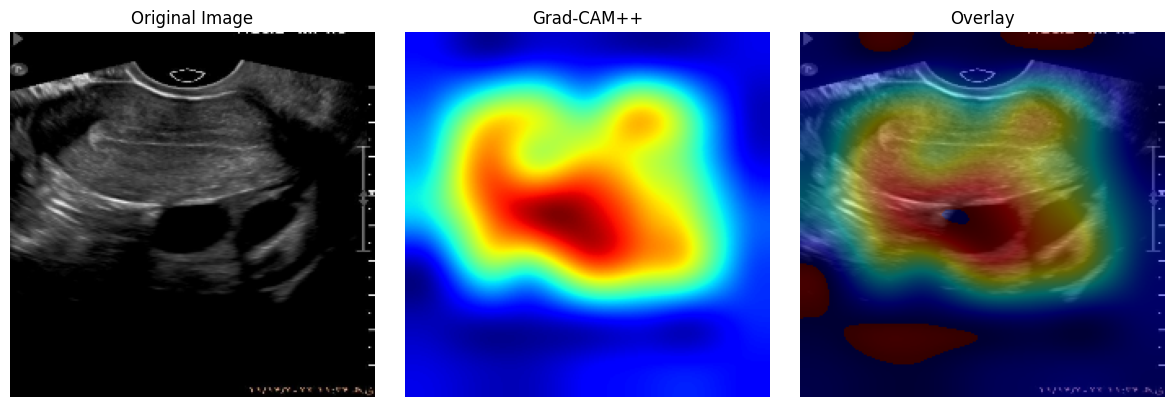

In [3]:
# ==========================================================
# FINAL TESTING + GRAD-CAM++ (ROBUST & VERSION-INDEPENDENT)
# ==========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random
from torchvision.models import swin_t, Swin_T_Weights
from torchvision.datasets import ImageFolder
from torchvision import transforms
from PIL import Image

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# =========================
# LOAD DATASET
# =========================
DATASET_PATH = "dataset"
dataset = ImageFolder(DATASET_PATH)
num_classes = len(dataset.classes)

# =========================
# LOAD TRAINED MODEL
# =========================
K_SHOT = 20   # 🔥 change (5,10,20,30)

model = swin_t(weights=Swin_T_Weights.DEFAULT)
model.head = nn.Linear(model.head.in_features, num_classes)

# SAME FREEZING STRATEGY AS TRAINING
for param in model.parameters():
    param.requires_grad = False

for param in model.features[-3:].parameters():
    param.requires_grad = True

for param in model.norm.parameters():
    param.requires_grad = True

for param in model.head.parameters():
    param.requires_grad = True

# LOAD TRAINED WEIGHTS
model.load_state_dict(
    torch.load(f"swin_{K_SHOT}shot_best.pth", map_location=device)
)

model = model.to(device)
model.eval()

# =========================
# RANDOM IMAGE
# =========================
img_path, true_label = random.choice(dataset.samples)
image = Image.open(img_path).convert("RGB")

print("Selected Image:", img_path)
print("True Class:", dataset.classes[true_label])

# =========================
# TRANSFORM (MATCH TRAIN)
# =========================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

input_tensor = transform(image).unsqueeze(0).to(device)

# =========================
# GRAD-CAM HOOKS
# =========================
features = []
gradients = []

def forward_hook(module, input, output):
    features.clear()
    features.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.clear()
    gradients.append(grad_output[0])

# =========================
# AUTO FIND BEST LAYER (FIXED)
# =========================
target_layer = None

for name, module in reversed(list(model.named_modules())):
    if isinstance(module, torch.nn.LayerNorm):
        target_layer = module
        print("Hooking Layer:", name)
        break

target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# =========================
# FORWARD + BACKWARD
# =========================
output = model(input_tensor)
pred_class = output.argmax(dim=1)

model.zero_grad()
output[0, pred_class].backward()

print("Predicted Class:", dataset.classes[pred_class.item()])

# =========================
# FEATURE MAP PROCESSING
# =========================
feature_map = features[0]
grad = gradients[0]

# HANDLE BOTH POSSIBLE SHAPES
if len(feature_map.shape) == 3:
    B, N, C = feature_map.shape
    H = W = int(np.sqrt(N))
    feature_map = feature_map.view(B, H, W, C)

# Convert to [C,H,W]
feature_map = feature_map[0].permute(2,0,1)
grad = grad[0].permute(2,0,1)

# =========================
# GRAD-CAM++

# =========================
grads = grad
grads_power_2 = grads ** 2
grads_power_3 = grads ** 3

sum_activations = torch.sum(feature_map.view(feature_map.shape[0], -1), dim=1)
sum_activations = sum_activations.view(-1, 1, 1)

eps = 1e-8

alpha_num = grads_power_2
alpha_denom = 2 * grads_power_2 + sum_activations * grads_power_3
alpha_denom = torch.where(alpha_denom != 0.0, alpha_denom, torch.ones_like(alpha_denom))

alpha = alpha_num / (alpha_denom + eps)

positive_gradients = F.relu(grads)

weights = torch.sum(alpha * positive_gradients, dim=(1,2))

cam = torch.zeros(feature_map.shape[1:], device=device)

for i in range(len(weights)):
    cam += weights[i] * feature_map[i]

cam = F.relu(cam).detach().cpu().numpy()

# =========================
# NORMALIZATION
# =========================
cam = cam - cam.min()
cam = cam / (cam.max() + 1e-8)

cam = cv2.resize(cam, (224,224), interpolation=cv2.INTER_CUBIC)
cam = cv2.GaussianBlur(cam, (31,31), 0)

# =========================
# HEATMAP
# =========================
original = cv2.imread(img_path)
original = cv2.resize(original, (224,224))

heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
overlay = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

# =========================
# DISPLAY
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Grad-CAM++")
plt.imshow(cam, cmap="jet")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()

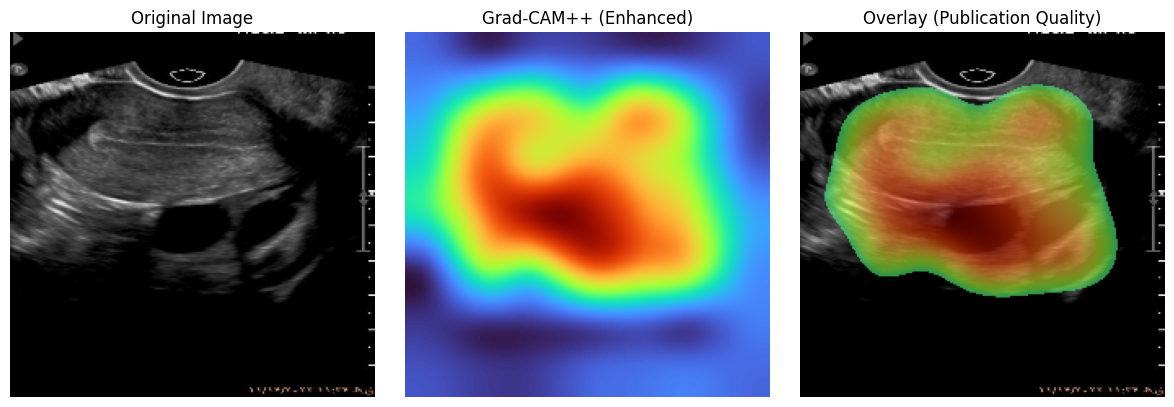

In [4]:

# =========================
# PROFESSIONAL NORMALIZATION
# =========================
cam = cam - np.min(cam)
cam = cam / (np.max(cam) + 1e-8)

# 🔥 upscale FIRST with high quality
cam = cv2.resize(cam, (224,224), interpolation=cv2.INTER_LANCZOS4)

# 🔥 edge-preserving smoothing (better than Gaussian)
cam = cv2.bilateralFilter(cam.astype(np.float32), 9, 75, 75)

# 🔥 sharpen CAM
kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
cam = cv2.filter2D(cam, -1, kernel)

# =========================
# HEATMAP (HIGH QUALITY)
# =========================
original = cv2.imread(img_path)
original = cv2.resize(original, (224,224))

# stronger contrast
cam_uint8 = np.uint8(255 * cam)
heatmap = cv2.applyColorMap(cam_uint8, cv2.COLORMAP_TURBO)  # 🔥 better than JET

# normalize brightness
heatmap = cv2.normalize(heatmap, None, 0, 255, cv2.NORM_MINMAX)

# =========================
# SMART OVERLAY (KEY FIX)
# =========================
# create mask for strong regions only
mask = cam > 0.4   # 🔥 threshold removes noise

overlay = original.copy()

# blend only important regions
overlay[mask] = cv2.addWeighted(
    original[mask], 0.4,
    heatmap[mask], 0.6,
    0
)

# =========================
# DISPLAY (CLEAN)
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Grad-CAM++ (Enhanced)")
plt.imshow(cam, cmap="turbo")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay (Publication Quality)")
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()


Using Device: cuda
Image: Dominant_Follicle_108.jpg
True Class: DominantFollicle
Hooking Layer: norm
Predicted Class: DominantFollicle


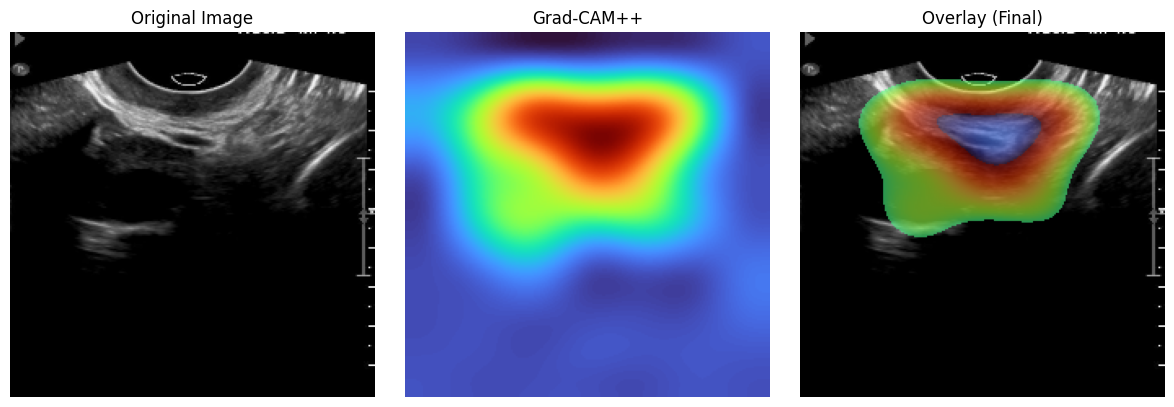

In [5]:
# ==========================================================
# FINAL TESTING + GRAD-CAM++ (PUBLICATION QUALITY)
# ==========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from torchvision.models import swin_t, Swin_T_Weights
from torchvision.datasets import ImageFolder
from torchvision import transforms
from PIL import Image

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# =========================
# LOAD DATASET
# =========================
DATASET_PATH = "dataset"
dataset = ImageFolder(DATASET_PATH)
num_classes = len(dataset.classes)

# =========================
# LOAD MODEL
# =========================
K_SHOT = 20   # 🔥 change (5,10,20,30)

model = swin_t(weights=Swin_T_Weights.DEFAULT)
model.head = nn.Linear(model.head.in_features, num_classes)

# SAME FREEZING AS TRAIN
for param in model.parameters():
    param.requires_grad = False

for param in model.features[-3:].parameters():
    param.requires_grad = True

for param in model.norm.parameters():
    param.requires_grad = True

for param in model.head.parameters():
    param.requires_grad = True

# LOAD TRAINED WEIGHTS
model.load_state_dict(
    torch.load(f"swin_{K_SHOT}shot_best.pth", map_location=device)
)

model = model.to(device)
model.eval()

# =========================
# FIXED IMAGE SELECTION (BEST)
# =========================
INDEX = 10   # 🔥 CHANGE THIS FOR DIFFERENT IMAGE

img_path, true_label = dataset.samples[INDEX]
image = Image.open(img_path).convert("RGB")

print("Image:", os.path.basename(img_path))
print("True Class:", dataset.classes[true_label])

# =========================
# TRANSFORM
# =========================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

input_tensor = transform(image).unsqueeze(0).to(device)

# =========================
# HOOKS
# =========================
features = []
gradients = []

def forward_hook(module, input, output):
    features.clear()
    features.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.clear()
    gradients.append(grad_output[0])

# AUTO FIND BEST LAYER (LayerNorm)
target_layer = None
for name, module in reversed(list(model.named_modules())):
    if isinstance(module, torch.nn.LayerNorm):
        target_layer = module
        print("Hooking Layer:", name)
        break

target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# =========================
# FORWARD + BACKWARD
# =========================
output = model(input_tensor)
pred_class = output.argmax(dim=1)

model.zero_grad()
output[0, pred_class].backward()

print("Predicted Class:", dataset.classes[pred_class.item()])

# =========================
# FEATURE PROCESSING
# =========================
feature_map = features[0]
grad = gradients[0]

if len(feature_map.shape) == 3:
    B, N, C = feature_map.shape
    H = W = int(np.sqrt(N))
    feature_map = feature_map.view(B, H, W, C)

feature_map = feature_map[0].permute(2,0,1)
grad = grad[0].permute(2,0,1)

# =========================
# GRAD-CAM++
# =========================
grads = grad
grads_power_2 = grads ** 2
grads_power_3 = grads ** 3

sum_activations = torch.sum(feature_map.view(feature_map.shape[0], -1), dim=1)
sum_activations = sum_activations.view(-1, 1, 1)

eps = 1e-8

alpha_num = grads_power_2
alpha_denom = 2 * grads_power_2 + sum_activations * grads_power_3
alpha_denom = torch.where(alpha_denom != 0.0, alpha_denom, torch.ones_like(alpha_denom))

alpha = alpha_num / (alpha_denom + eps)

positive_gradients = F.relu(grads)

weights = torch.sum(alpha * positive_gradients, dim=(1,2))

cam = torch.zeros(feature_map.shape[1:], device=device)

for i in range(len(weights)):
    cam += weights[i] * feature_map[i]

cam = F.relu(cam).detach().cpu().numpy()

# =========================
# PROFESSIONAL ENHANCEMENT
# =========================
cam = cam - np.min(cam)
cam = cam / (np.max(cam) + 1e-8)

# 🔥 enhance focus
cam = np.power(cam, 1.5)

# high-quality resize
cam = cv2.resize(cam, (224,224), interpolation=cv2.INTER_LANCZOS4)

# edge-preserving smoothing
cam = cv2.bilateralFilter(cam.astype(np.float32), 9, 75, 75)

# sharpen
kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
cam = cv2.filter2D(cam, -1, kernel)

# =========================
# HEATMAP
# =========================
original = cv2.imread(img_path)
original = cv2.resize(original, (224,224))

cam_uint8 = np.uint8(255 * cam)
heatmap = cv2.applyColorMap(cam_uint8, cv2.COLORMAP_TURBO)

# =========================
# SMART OVERLAY
# =========================
mask = cam > 0.4
overlay = original.copy()

overlay[mask] = cv2.addWeighted(
    original[mask], 0.4,
    heatmap[mask], 0.6,
    0
)

# =========================
# DISPLAY
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Grad-CAM++")
plt.imshow(cam, cmap="turbo")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay (Final)")
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()


Using Device: cuda
Image: Dominant_Follicle_126.jpg
True Class: DominantFollicle
Hooking Layer: norm
Predicted Class: DominantFollicle


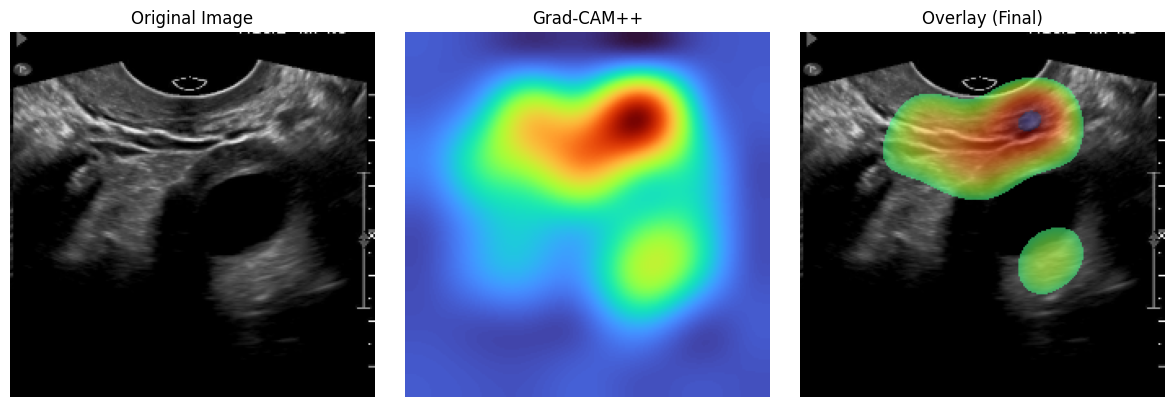

In [6]:
# ==========================================================
# FINAL TESTING + GRAD-CAM++ (PUBLICATION QUALITY)
# ==========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from torchvision.models import swin_t, Swin_T_Weights
from torchvision.datasets import ImageFolder
from torchvision import transforms
from PIL import Image

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# =========================
# LOAD DATASET
# =========================
DATASET_PATH = "dataset"
dataset = ImageFolder(DATASET_PATH)
num_classes = len(dataset.classes)

# =========================
# LOAD MODEL
# =========================
K_SHOT = 20   # 🔥 change (5,10,20,30)

model = swin_t(weights=Swin_T_Weights.DEFAULT)
model.head = nn.Linear(model.head.in_features, num_classes)

# SAME FREEZING AS TRAIN
for param in model.parameters():
    param.requires_grad = False

for param in model.features[-3:].parameters():
    param.requires_grad = True

for param in model.norm.parameters():
    param.requires_grad = True

for param in model.head.parameters():
    param.requires_grad = True

# LOAD TRAINED WEIGHTS
model.load_state_dict(
    torch.load(f"swin_{K_SHOT}shot_best.pth", map_location=device)
)

model = model.to(device)
model.eval()

# =========================
# FIXED IMAGE SELECTION (BEST)
# =========================
INDEX = 30   # 🔥 CHANGE THIS FOR DIFFERENT IMAGE

img_path, true_label = dataset.samples[INDEX]
image = Image.open(img_path).convert("RGB")

print("Image:", os.path.basename(img_path))
print("True Class:", dataset.classes[true_label])

# =========================
# TRANSFORM
# =========================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

input_tensor = transform(image).unsqueeze(0).to(device)

# =========================
# HOOKS
# =========================
features = []
gradients = []

def forward_hook(module, input, output):
    features.clear()
    features.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.clear()
    gradients.append(grad_output[0])

# AUTO FIND BEST LAYER (LayerNorm)
target_layer = None
for name, module in reversed(list(model.named_modules())):
    if isinstance(module, torch.nn.LayerNorm):
        target_layer = module
        print("Hooking Layer:", name)
        break

target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# =========================
# FORWARD + BACKWARD
# =========================
output = model(input_tensor)
pred_class = output.argmax(dim=1)

model.zero_grad()
output[0, pred_class].backward()

print("Predicted Class:", dataset.classes[pred_class.item()])

# =========================
# FEATURE PROCESSING
# =========================
feature_map = features[0]
grad = gradients[0]

if len(feature_map.shape) == 3:
    B, N, C = feature_map.shape
    H = W = int(np.sqrt(N))
    feature_map = feature_map.view(B, H, W, C)

feature_map = feature_map[0].permute(2,0,1)
grad = grad[0].permute(2,0,1)

# =========================
# GRAD-CAM++
# =========================
grads = grad
grads_power_2 = grads ** 2
grads_power_3 = grads ** 3

sum_activations = torch.sum(feature_map.view(feature_map.shape[0], -1), dim=1)
sum_activations = sum_activations.view(-1, 1, 1)

eps = 1e-8

alpha_num = grads_power_2
alpha_denom = 2 * grads_power_2 + sum_activations * grads_power_3
alpha_denom = torch.where(alpha_denom != 0.0, alpha_denom, torch.ones_like(alpha_denom))

alpha = alpha_num / (alpha_denom + eps)

positive_gradients = F.relu(grads)

weights = torch.sum(alpha * positive_gradients, dim=(1,2))

cam = torch.zeros(feature_map.shape[1:], device=device)

for i in range(len(weights)):
    cam += weights[i] * feature_map[i]

cam = F.relu(cam).detach().cpu().numpy()

# =========================
# PROFESSIONAL ENHANCEMENT
# =========================
cam = cam - np.min(cam)
cam = cam / (np.max(cam) + 1e-8)

# 🔥 enhance focus
cam = np.power(cam, 1.5)

# high-quality resize
cam = cv2.resize(cam, (224,224), interpolation=cv2.INTER_LANCZOS4)

# edge-preserving smoothing
cam = cv2.bilateralFilter(cam.astype(np.float32), 9, 75, 75)

# sharpen
kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
cam = cv2.filter2D(cam, -1, kernel)

# =========================
# HEATMAP
# =========================
original = cv2.imread(img_path)
original = cv2.resize(original, (224,224))

cam_uint8 = np.uint8(255 * cam)
heatmap = cv2.applyColorMap(cam_uint8, cv2.COLORMAP_TURBO)

# =========================
# SMART OVERLAY
# =========================
mask = cam > 0.4
overlay = original.copy()

overlay[mask] = cv2.addWeighted(
    original[mask], 0.4,
    heatmap[mask], 0.6,
    0
)

# =========================
# DISPLAY
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Grad-CAM++")
plt.imshow(cam, cmap="turbo")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay (Final)")
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()


Using Device: cuda
Image: Dominant_Follicle_135.jpg
True Class: DominantFollicle
Hooking Layer: norm
Predicted Class: DominantFollicle


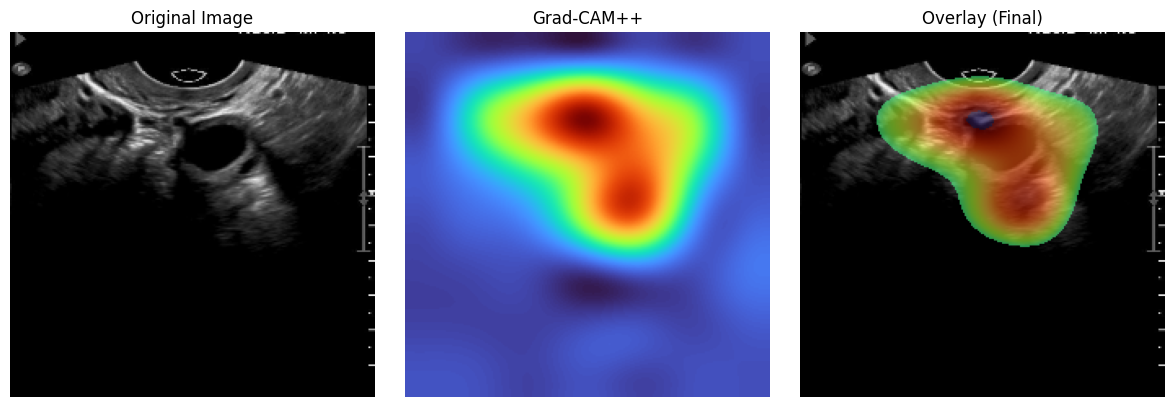

In [7]:
# ==========================================================
# FINAL TESTING + GRAD-CAM++ (PUBLICATION QUALITY)
# ==========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from torchvision.models import swin_t, Swin_T_Weights
from torchvision.datasets import ImageFolder
from torchvision import transforms
from PIL import Image

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# =========================
# LOAD DATASET
# =========================
DATASET_PATH = "dataset"
dataset = ImageFolder(DATASET_PATH)
num_classes = len(dataset.classes)

# =========================
# LOAD MODEL
# =========================
K_SHOT = 20   # 🔥 change (5,10,20,30)

model = swin_t(weights=Swin_T_Weights.DEFAULT)
model.head = nn.Linear(model.head.in_features, num_classes)

# SAME FREEZING AS TRAIN
for param in model.parameters():
    param.requires_grad = False

for param in model.features[-3:].parameters():
    param.requires_grad = True

for param in model.norm.parameters():
    param.requires_grad = True

for param in model.head.parameters():
    param.requires_grad = True

# LOAD TRAINED WEIGHTS
model.load_state_dict(
    torch.load(f"swin_{K_SHOT}shot_best.pth", map_location=device)
)

model = model.to(device)
model.eval()

# =========================
# FIXED IMAGE SELECTION (BEST)
# =========================
INDEX = 40  # 🔥 CHANGE THIS FOR DIFFERENT IMAGE

img_path, true_label = dataset.samples[INDEX]
image = Image.open(img_path).convert("RGB")

print("Image:", os.path.basename(img_path))
print("True Class:", dataset.classes[true_label])

# =========================
# TRANSFORM
# =========================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

input_tensor = transform(image).unsqueeze(0).to(device)

# =========================
# HOOKS
# =========================
features = []
gradients = []

def forward_hook(module, input, output):
    features.clear()
    features.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.clear()
    gradients.append(grad_output[0])

# AUTO FIND BEST LAYER (LayerNorm)
target_layer = None
for name, module in reversed(list(model.named_modules())):
    if isinstance(module, torch.nn.LayerNorm):
        target_layer = module
        print("Hooking Layer:", name)
        break

target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# =========================
# FORWARD + BACKWARD
# =========================
output = model(input_tensor)
pred_class = output.argmax(dim=1)

model.zero_grad()
output[0, pred_class].backward()

print("Predicted Class:", dataset.classes[pred_class.item()])

# =========================
# FEATURE PROCESSING
# =========================
feature_map = features[0]
grad = gradients[0]

if len(feature_map.shape) == 3:
    B, N, C = feature_map.shape
    H = W = int(np.sqrt(N))
    feature_map = feature_map.view(B, H, W, C)

feature_map = feature_map[0].permute(2,0,1)
grad = grad[0].permute(2,0,1)

# =========================
# GRAD-CAM++
# =========================
grads = grad
grads_power_2 = grads ** 2
grads_power_3 = grads ** 3

sum_activations = torch.sum(feature_map.view(feature_map.shape[0], -1), dim=1)
sum_activations = sum_activations.view(-1, 1, 1)

eps = 1e-8

alpha_num = grads_power_2
alpha_denom = 2 * grads_power_2 + sum_activations * grads_power_3
alpha_denom = torch.where(alpha_denom != 0.0, alpha_denom, torch.ones_like(alpha_denom))

alpha = alpha_num / (alpha_denom + eps)

positive_gradients = F.relu(grads)

weights = torch.sum(alpha * positive_gradients, dim=(1,2))

cam = torch.zeros(feature_map.shape[1:], device=device)

for i in range(len(weights)):
    cam += weights[i] * feature_map[i]

cam = F.relu(cam).detach().cpu().numpy()

# =========================
# PROFESSIONAL ENHANCEMENT
# =========================
cam = cam - np.min(cam)
cam = cam / (np.max(cam) + 1e-8)

# 🔥 enhance focus
cam = np.power(cam, 1.5)

# high-quality resize
cam = cv2.resize(cam, (224,224), interpolation=cv2.INTER_LANCZOS4)

# edge-preserving smoothing
cam = cv2.bilateralFilter(cam.astype(np.float32), 9, 75, 75)

# sharpen
kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
cam = cv2.filter2D(cam, -1, kernel)

# =========================
# HEATMAP
# =========================
original = cv2.imread(img_path)
original = cv2.resize(original, (224,224))

cam_uint8 = np.uint8(255 * cam)
heatmap = cv2.applyColorMap(cam_uint8, cv2.COLORMAP_TURBO)

# =========================
# SMART OVERLAY
# =========================
mask = cam > 0.4
overlay = original.copy()

overlay[mask] = cv2.addWeighted(
    original[mask], 0.4,
    heatmap[mask], 0.6,
    0
)

# =========================
# DISPLAY
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Grad-CAM++")
plt.imshow(cam, cmap="turbo")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay (Final)")
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()


Using Device: cuda
Image: Dominant_Follicle_144.jpg
True Class: DominantFollicle
Hooking Layer: norm
Predicted Class: DominantFollicle


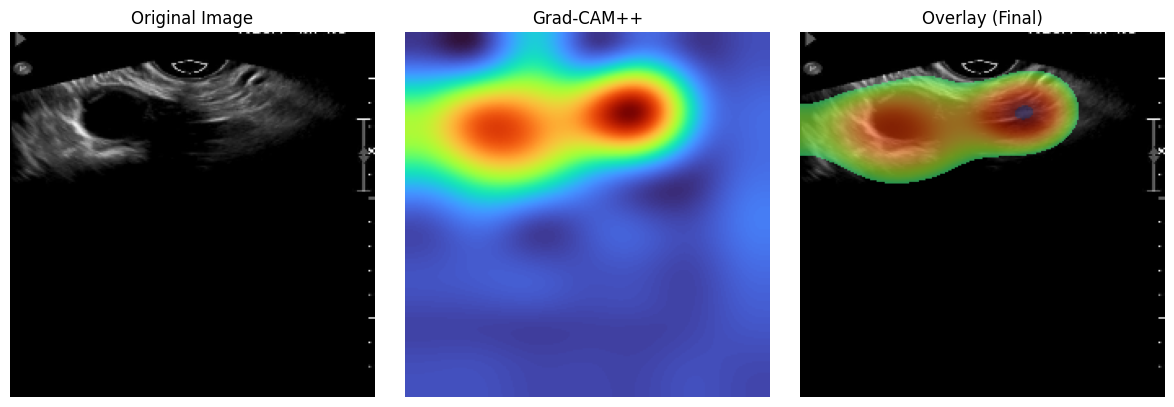

In [8]:
# ==========================================================
# FINAL TESTING + GRAD-CAM++ (PUBLICATION QUALITY)
# ==========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from torchvision.models import swin_t, Swin_T_Weights
from torchvision.datasets import ImageFolder
from torchvision import transforms
from PIL import Image

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# =========================
# LOAD DATASET
# =========================
DATASET_PATH = "dataset"
dataset = ImageFolder(DATASET_PATH)
num_classes = len(dataset.classes)

# =========================
# LOAD MODEL
# =========================
K_SHOT = 20   # 🔥 change (5,10,20,30)

model = swin_t(weights=Swin_T_Weights.DEFAULT)
model.head = nn.Linear(model.head.in_features, num_classes)

# SAME FREEZING AS TRAIN
for param in model.parameters():
    param.requires_grad = False

for param in model.features[-3:].parameters():
    param.requires_grad = True

for param in model.norm.parameters():
    param.requires_grad = True

for param in model.head.parameters():
    param.requires_grad = True

# LOAD TRAINED WEIGHTS
model.load_state_dict(
    torch.load(f"swin_{K_SHOT}shot_best.pth", map_location=device)
)

model = model.to(device)
model.eval()

# =========================
# FIXED IMAGE SELECTION (BEST)
# =========================
INDEX = 50   # 🔥 CHANGE THIS FOR DIFFERENT IMAGE

img_path, true_label = dataset.samples[INDEX]
image = Image.open(img_path).convert("RGB")

print("Image:", os.path.basename(img_path))
print("True Class:", dataset.classes[true_label])

# =========================
# TRANSFORM
# =========================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

input_tensor = transform(image).unsqueeze(0).to(device)

# =========================
# HOOKS
# =========================
features = []
gradients = []

def forward_hook(module, input, output):
    features.clear()
    features.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.clear()
    gradients.append(grad_output[0])

# AUTO FIND BEST LAYER (LayerNorm)
target_layer = None
for name, module in reversed(list(model.named_modules())):
    if isinstance(module, torch.nn.LayerNorm):
        target_layer = module
        print("Hooking Layer:", name)
        break

target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# =========================
# FORWARD + BACKWARD
# =========================
output = model(input_tensor)
pred_class = output.argmax(dim=1)

model.zero_grad()
output[0, pred_class].backward()

print("Predicted Class:", dataset.classes[pred_class.item()])

# =========================
# FEATURE PROCESSING
# =========================
feature_map = features[0]
grad = gradients[0]

if len(feature_map.shape) == 3:
    B, N, C = feature_map.shape
    H = W = int(np.sqrt(N))
    feature_map = feature_map.view(B, H, W, C)

feature_map = feature_map[0].permute(2,0,1)
grad = grad[0].permute(2,0,1)

# =========================
# GRAD-CAM++
# =========================
grads = grad
grads_power_2 = grads ** 2
grads_power_3 = grads ** 3

sum_activations = torch.sum(feature_map.view(feature_map.shape[0], -1), dim=1)
sum_activations = sum_activations.view(-1, 1, 1)

eps = 1e-8

alpha_num = grads_power_2
alpha_denom = 2 * grads_power_2 + sum_activations * grads_power_3
alpha_denom = torch.where(alpha_denom != 0.0, alpha_denom, torch.ones_like(alpha_denom))

alpha = alpha_num / (alpha_denom + eps)

positive_gradients = F.relu(grads)

weights = torch.sum(alpha * positive_gradients, dim=(1,2))

cam = torch.zeros(feature_map.shape[1:], device=device)

for i in range(len(weights)):
    cam += weights[i] * feature_map[i]

cam = F.relu(cam).detach().cpu().numpy()

# =========================
# PROFESSIONAL ENHANCEMENT
# =========================
cam = cam - np.min(cam)
cam = cam / (np.max(cam) + 1e-8)

# 🔥 enhance focus
cam = np.power(cam, 1.5)

# high-quality resize
cam = cv2.resize(cam, (224,224), interpolation=cv2.INTER_LANCZOS4)

# edge-preserving smoothing
cam = cv2.bilateralFilter(cam.astype(np.float32), 9, 75, 75)

# sharpen
kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
cam = cv2.filter2D(cam, -1, kernel)

# =========================
# HEATMAP
# =========================
original = cv2.imread(img_path)
original = cv2.resize(original, (224,224))

cam_uint8 = np.uint8(255 * cam)
heatmap = cv2.applyColorMap(cam_uint8, cv2.COLORMAP_TURBO)

# =========================
# SMART OVERLAY
# =========================
mask = cam > 0.4
overlay = original.copy()

overlay[mask] = cv2.addWeighted(
    original[mask], 0.4,
    heatmap[mask], 0.6,
    0
)

# =========================
# DISPLAY
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Grad-CAM++")
plt.imshow(cam, cmap="turbo")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay (Final)")
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()


Classes: ['DominantFollicle', 'Normal', 'PCO']
Model loaded successfully!
Prediction completed!


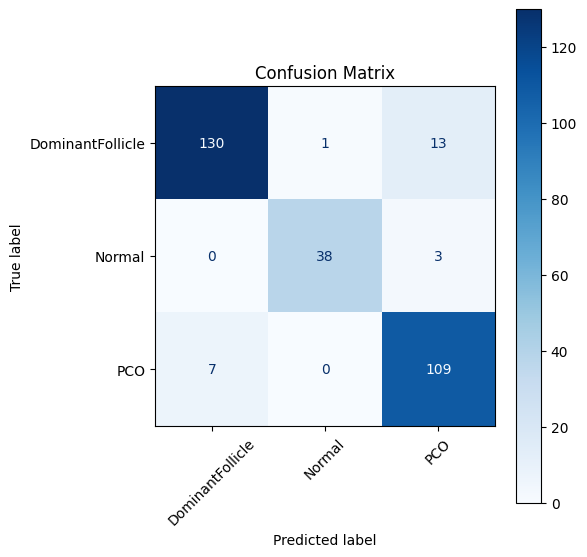

Confusion Matrix saved at: confusion_matrix.png


In [2]:


import torch
import numpy as np
import matplotlib.pyplot as plt
import os

from torchvision.datasets import ImageFolder
from torchvision import transforms
from torchvision.models import swin_t, Swin_T_Weights
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ========================
# SETTINGS
# ========================

DATASET_PATH = "dataset"
MODEL_PATH = "swin_30shot_best.pth"   # change if needed
SAVE_PATH = "confusion_matrix.png"

# ✅ SAFE DEVICE (prevents OOM)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Optional (clear GPU memory)
torch.cuda.empty_cache()

# ========================
# TRANSFORM (NO AUGMENTATION)
# ========================

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ========================
# LOAD DATASET
# ========================

dataset = ImageFolder(DATASET_PATH, transform=transform)
class_names = dataset.classes

loader = DataLoader(dataset, batch_size=8, shuffle=False)  # small batch = safe

print("Classes:", class_names)

# ========================
# LOAD MODEL (SAFE WAY 🔥)
# ========================

model = swin_t(weights=Swin_T_Weights.DEFAULT)
model.head = torch.nn.Linear(model.head.in_features, len(class_names))

# ✅ LOAD ON CPU FIRST (fixes CUDA OOM)
state_dict = torch.load(MODEL_PATH, map_location="cpu")
model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

print("Model loaded successfully!")

# ========================
# PREDICTIONS
# ========================

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Prediction completed!")

# ========================
# CONFUSION MATRIX
# ========================

cm = confusion_matrix(all_labels, all_preds)

# ========================
# DISPLAY + SAVE
# ========================

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix")
plt.tight_layout()

plt.savefig(SAVE_PATH)
plt.show()

print("Confusion Matrix saved at:", SAVE_PATH)


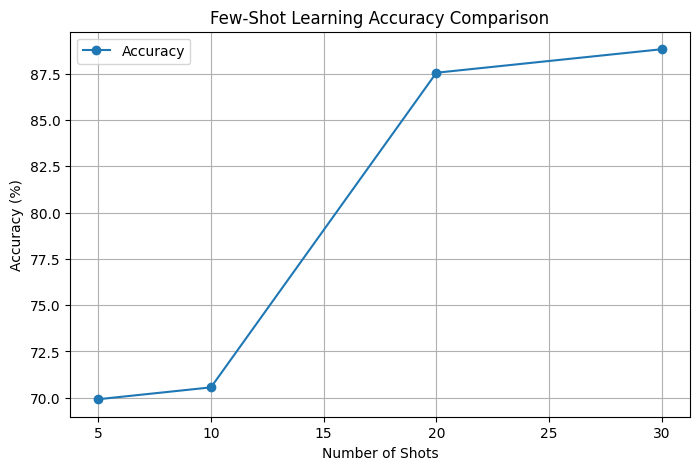

In [3]:
# ==========================================================
# FEW-SHOT ACCURACY GRAPH (YOUR RESULTS)
# ==========================================================

import matplotlib.pyplot as plt

# Shots
shots = [5, 10, 20, 30]

# Your Accuracy Values
accuracy = [69.92, 70.56, 87.56, 88.83]

# Plot
plt.figure(figsize=(8,5))

plt.plot(shots, accuracy, marker='o', label='Accuracy')

plt.xlabel("Number of Shots")
plt.ylabel("Accuracy (%)")
plt.title("Few-Shot Learning Accuracy Comparison")

plt.legend()
plt.grid(True)

plt.savefig("accuracy_comparison.png")
plt.show()

In [4]:
# ==========================================================
# SINGLE CELL: PREDICTION + CONFIDENCE SCORE
# ==========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import swin_t, Swin_T_Weights
from torchvision.datasets import ImageFolder
from torchvision import transforms
from PIL import Image
import random

# -------------------------
# DEVICE
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# DATASET
# -------------------------
DATASET_PATH = "dataset"

dataset = ImageFolder(DATASET_PATH)
class_names = dataset.classes

# -------------------------
# MODEL LOAD (SAFE)
# -------------------------
model = swin_t(weights=Swin_T_Weights.DEFAULT)
model.head = nn.Linear(model.head.in_features, len(class_names))

state_dict = torch.load("swin_30shot_best.pth", map_location="cpu")
model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

# -------------------------
# TRANSFORM
# -------------------------
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# -------------------------
# RANDOM IMAGE
# -------------------------
img_path, true_label = random.choice(dataset.samples)
image = Image.open(img_path).convert("RGB")

input_tensor = transform(image).unsqueeze(0).to(device)

print("Image:", img_path)
print("Actual Class:", class_names[true_label])

# -------------------------
# PREDICTION + CONFIDENCE
# -------------------------
with torch.no_grad():
    output = model(input_tensor)

    probs = F.softmax(output, dim=1)
    confidence, pred_class = torch.max(probs, dim=1)

print("Predicted Class:", class_names[pred_class.item()])
print("Confidence: {:.2f}%".format(confidence.item()*100))


Image: dataset/PCO/PCO_10.jpg
Actual Class: PCO
Predicted Class: PCO
Confidence: 96.71%


In [7]:
# ==========================================================
# SINGLE CELL: 5 RANDOM IMAGES + PREDICTION + CONFIDENCE
# ==========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import swin_t, Swin_T_Weights
from torchvision.datasets import ImageFolder
from torchvision import transforms
from PIL import Image
import random

# -------------------------
# DEVICE
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# DATASET
# -------------------------
DATASET_PATH = "dataset"

dataset = ImageFolder(DATASET_PATH)
class_names = dataset.classes

# -------------------------
# MODEL LOAD (SAFE)
# -------------------------
model = swin_t(weights=Swin_T_Weights.DEFAULT)
model.head = nn.Linear(model.head.in_features, len(class_names))

state_dict = torch.load("swin_30shot_best.pth", map_location="cpu")
model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

# -------------------------
# TRANSFORM
# -------------------------
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# -------------------------
# SELECT 5 RANDOM IMAGES
# -------------------------
sample_images = random.sample(dataset.samples, 5)

# -------------------------
# PREDICTION LOOP
# -------------------------
print("\n===== RANDOM SAMPLE PREDICTIONS =====\n")

with torch.no_grad():
    for i, (img_path, true_label) in enumerate(sample_images):

        image = Image.open(img_path).convert("RGB")
        input_tensor = transform(image).unsqueeze(0).to(device)

        output = model(input_tensor)

        probs = F.softmax(output, dim=1)
        confidence, pred_class = torch.max(probs, dim=1)

        print(f"Sample {i+1}")
        print("Image Path      :", img_path)
        print("Actual Class    :", class_names[true_label])
        print("Predicted Class :", class_names[pred_class.item()])
        print("Confidence      : {:.2f}%".format(confidence.item()*100))
        print("-"*50)



===== RANDOM SAMPLE PREDICTIONS =====

Sample 1
Image Path      : dataset/Normal/Normal_20.jpg
Actual Class    : Normal
Predicted Class : Normal
Confidence      : 97.25%
--------------------------------------------------
Sample 2
Image Path      : dataset/DominantFollicle/Dominant_Follicle_69.jpg
Actual Class    : DominantFollicle
Predicted Class : DominantFollicle
Confidence      : 98.22%
--------------------------------------------------
Sample 3
Image Path      : dataset/DominantFollicle/Dominant_Follicle_80.jpg
Actual Class    : DominantFollicle
Predicted Class : DominantFollicle
Confidence      : 97.89%
--------------------------------------------------
Sample 4
Image Path      : dataset/Normal/Normal_41.jpg
Actual Class    : Normal
Predicted Class : Normal
Confidence      : 97.38%
--------------------------------------------------
Sample 5
Image Path      : dataset/DominantFollicle/Dominant_Follicle_124.jpg
Actual Class    : DominantFollicle
Predicted Class : DominantFollicle
Co